In [1]:
import pandas as pd

demand = pd.read_csv("../data/raw/demand_forecasting.csv")
inventory = pd.read_csv("../data/raw/inventory_monitoring.csv")
pricing = pd.read_csv("../data/raw/pricing_optimization.csv")

In [2]:
datasets = {
    "Demand": demand,
    "Inventory": inventory,
    "Pricing": pricing
}

for name, df in datasets.items():

    print("\n" + "="*60)
    print(name)
    print("="*60)

    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())


Demand
Shape: (10000, 10)

Columns:
['Product ID', 'Date', 'Store ID', 'Sales Quantity', 'Price', 'Promotions', 'Seasonality Factors', 'External Factors', 'Demand Trend', 'Customer Segments']

Inventory
Shape: (10000, 9)

Columns:
['Product ID', 'Store ID', 'Stock Levels', 'Supplier Lead Time (days)', 'Stockout Frequency', 'Reorder Point', 'Expiry Date', 'Warehouse Capacity', 'Order Fulfillment Time (days)']

Pricing
Shape: (10000, 10)

Columns:
['Product ID', 'Store ID', 'Price', 'Competitor Prices', 'Discounts', 'Sales Volume', 'Customer Reviews', 'Return Rate (%)', 'Storage Cost', 'Elasticity Index']


In [3]:
for name, df in datasets.items():

    print("\n" + "="*60)
    print(name)
    print("="*60)

    print(df.dtypes)


Demand
Product ID               int64
Date                    object
Store ID                 int64
Sales Quantity           int64
Price                  float64
Promotions              object
Seasonality Factors     object
External Factors        object
Demand Trend            object
Customer Segments       object
dtype: object

Inventory
Product ID                        int64
Store ID                          int64
Stock Levels                      int64
Supplier Lead Time (days)         int64
Stockout Frequency                int64
Reorder Point                     int64
Expiry Date                      object
Warehouse Capacity                int64
Order Fulfillment Time (days)     int64
dtype: object

Pricing
Product ID             int64
Store ID               int64
Price                float64
Competitor Prices    float64
Discounts            float64
Sales Volume           int64
Customer Reviews       int64
Return Rate (%)      float64
Storage Cost         float64
Elasticity In

Data Quality Assessment

In [4]:
datasets = {
    "Demand": demand,
    "Inventory": inventory,
    "Pricing": pricing
}

for name, df in datasets.items():

    print("\n" + "="*60)
    print(name)
    print("="*60)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())


Demand

Missing Values:
Product ID                0
Date                      0
Store ID                  0
Sales Quantity            0
Price                     0
Promotions                0
Seasonality Factors    3315
External Factors       2426
Demand Trend              0
Customer Segments         0
dtype: int64

Duplicate Rows:
0

Inventory

Missing Values:
Product ID                       0
Store ID                         0
Stock Levels                     0
Supplier Lead Time (days)        0
Stockout Frequency               0
Reorder Point                    0
Expiry Date                      0
Warehouse Capacity               0
Order Fulfillment Time (days)    0
dtype: int64

Duplicate Rows:
0

Pricing

Missing Values:
Product ID           0
Store ID             0
Price                0
Competitor Prices    0
Discounts            0
Sales Volume         0
Customer Reviews     0
Return Rate (%)      0
Storage Cost         0
Elasticity Index     0
dtype: int64

Duplicate Rows:
0


In [7]:
print(demand["Seasonality Factors"].value_counts(dropna=False))

print("\n" + "="*50 + "\n")

print(demand["External Factors"].value_counts(dropna=False))

Seasonality Factors
Holiday     3363
Festival    3322
None        3315
Name: count, dtype: int64


External Factors
Weather               2556
Competitor Pricing    2518
Economic Indicator    2500
None                  2426
Name: count, dtype: int64


In [6]:
demand["Seasonality Factors"] = demand["Seasonality Factors"].fillna("None")
demand["External Factors"] = demand["External Factors"].fillna("None")

In [8]:
print(demand.isnull().sum())

Product ID             0
Date                   0
Store ID               0
Sales Quantity         0
Price                  0
Promotions             0
Seasonality Factors    0
External Factors       0
Demand Trend           0
Customer Segments      0
dtype: int64


In [9]:
demand["Date"] = pd.to_datetime(demand["Date"])

inventory["Expiry Date"] = pd.to_datetime(
    inventory["Expiry Date"]
)

In [10]:
print(demand.dtypes)
print(inventory.dtypes)

Product ID                      int64
Date                   datetime64[ns]
Store ID                        int64
Sales Quantity                  int64
Price                         float64
Promotions                     object
Seasonality Factors            object
External Factors               object
Demand Trend                   object
Customer Segments              object
dtype: object
Product ID                                int64
Store ID                                  int64
Stock Levels                              int64
Supplier Lead Time (days)                 int64
Stockout Frequency                        int64
Reorder Point                             int64
Expiry Date                      datetime64[ns]
Warehouse Capacity                        int64
Order Fulfillment Time (days)             int64
dtype: object


Saving the processed dataaset

In [11]:
demand.to_csv(
    "../data/processed/demand_cleaned.csv",
    index=False
)

inventory.to_csv(
    "../data/processed/inventory_cleaned.csv",
    index=False
)

pricing.to_csv(
    "../data/processed/pricing_cleaned.csv",
    index=False
)

# EDA

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

Sales Quantity Distribution

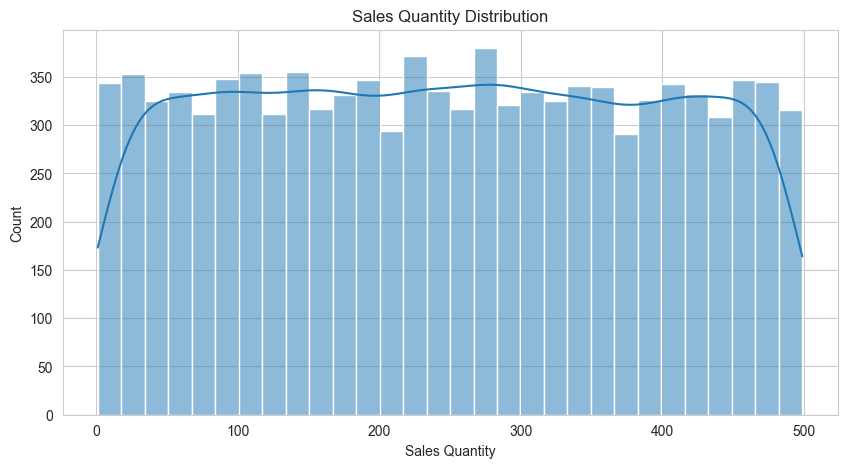

In [41]:
plt.figure(figsize=(10,5))

sns.histplot(
    demand["Sales Quantity"],
    bins=30,
    kde=True
)

plt.title("Sales Quantity Distribution")
plt.savefig(
    "../reports/figures/demand/sales_quantity_distribution.png",
    bbox_inches="tight"
)
plt.show()

Demand Trend Analysis

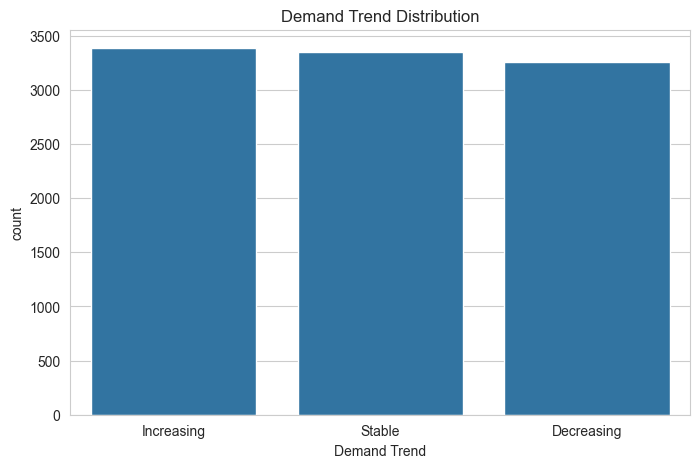

In [42]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=demand,
    x="Demand Trend"
)

plt.title("Demand Trend Distribution")
plt.savefig(
    "../reports/figures/demand/demand_trend_distribution.png",
    bbox_inches="tight"
)
plt.show()

Customer Segment Analysis

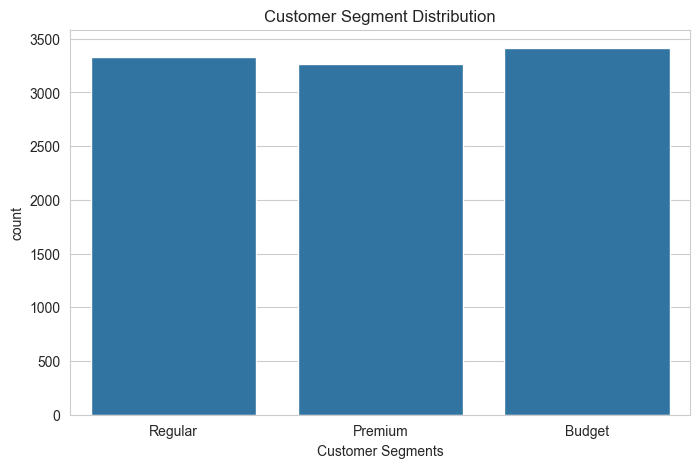

In [43]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=demand,
    x="Customer Segments"
)

plt.title("Customer Segment Distribution")
plt.savefig(
    "../reports/figures/demand/customer_segment_distribution.png",
    bbox_inches="tight"
)
plt.show()

Seasonality Analysis

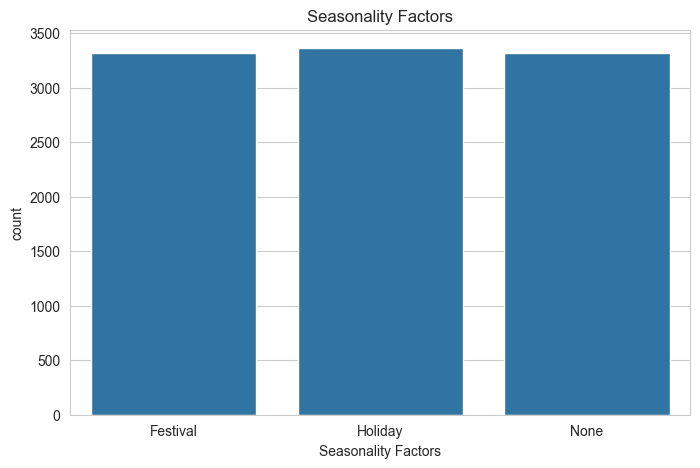

In [44]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=demand,
    x="Seasonality Factors"
)

plt.title("Seasonality Factors")
plt.savefig(
    "../reports/figures/demand/seasonality_factors_distribution.png",
    bbox_inches="tight"
)
plt.show()

Stock Level Distribution

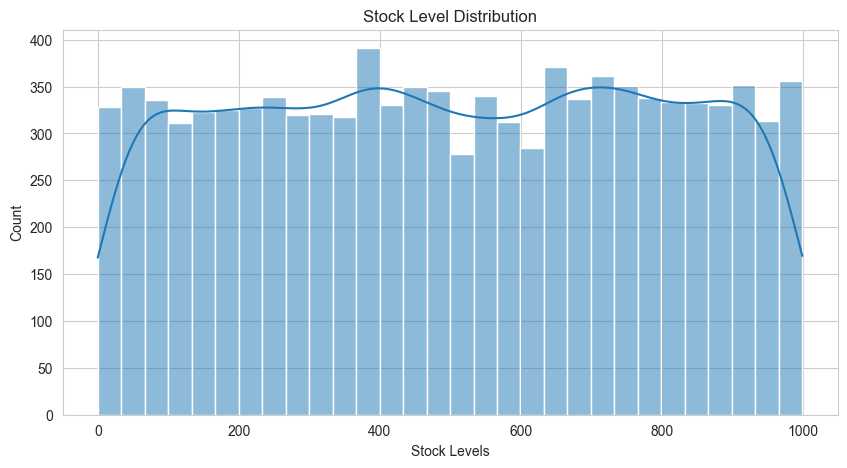

In [45]:
plt.figure(figsize=(10,5))

sns.histplot(
    inventory["Stock Levels"],
    bins=30,
    kde=True
)

plt.title("Stock Level Distribution")
plt.savefig(
    "../reports/figures/inventory/stock_level_distribution.png",
    bbox_inches="tight"
)
plt.show()

Stockout Frequency

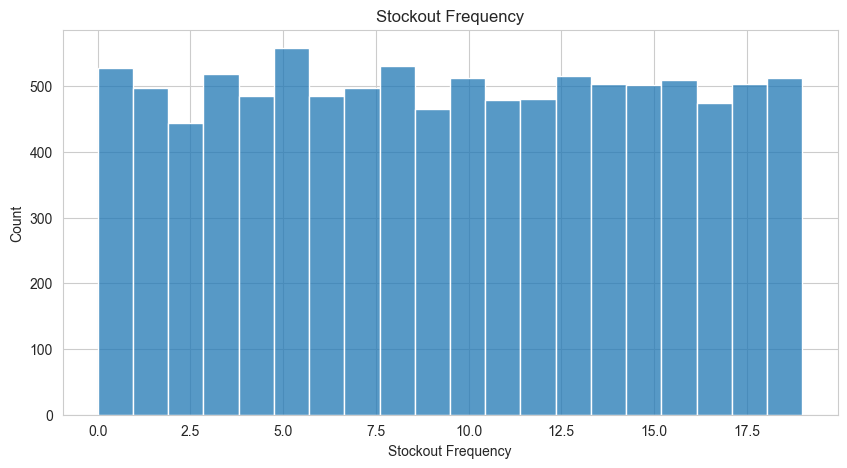

In [46]:
plt.figure(figsize=(10,5))

sns.histplot(
    inventory["Stockout Frequency"],
    bins=20
)

plt.title("Stockout Frequency")
plt.savefig(
    "../reports/figures/inventory/stockout_frequency_distribution.png",
    bbox_inches="tight"
)
plt.show()

Reorder Point Distribution

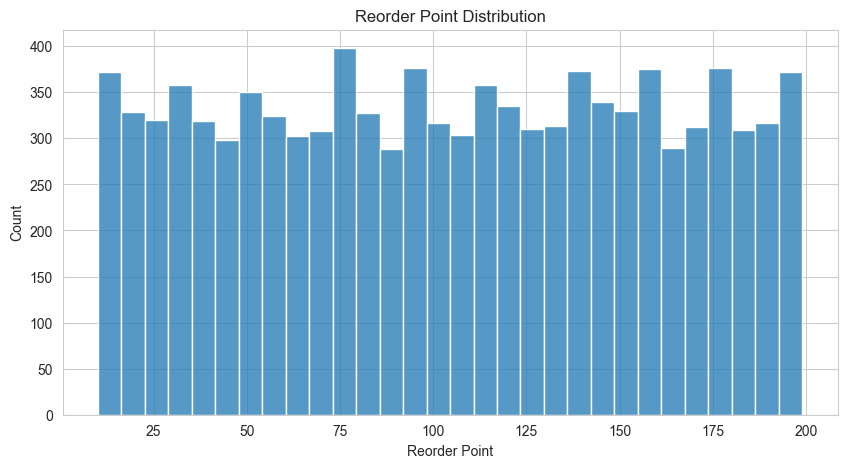

In [47]:
plt.figure(figsize=(10,5))

sns.histplot(
    inventory["Reorder Point"],
    bins=30
)

plt.title("Reorder Point Distribution")
plt.savefig(
    "../reports/figures/inventory/reorder_point_distribution.png",
    bbox_inches="tight"
)
plt.show()

Pricing Analysis

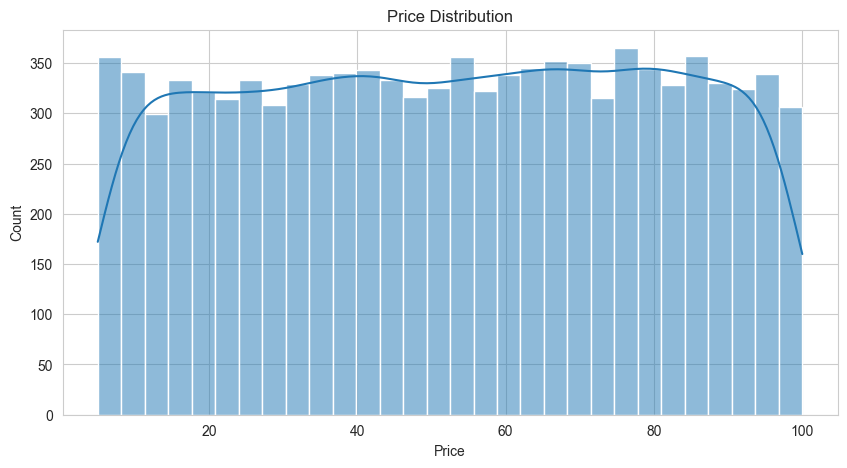

In [48]:
plt.figure(figsize=(10,5))

sns.histplot(
    pricing["Price"],
    bins=30,
    kde=True
)

plt.title("Price Distribution")
plt.savefig(
    "../reports/figures/pricing/price_distribution.png",
    bbox_inches="tight"
)
plt.show()

Competitor Price vs Our Price

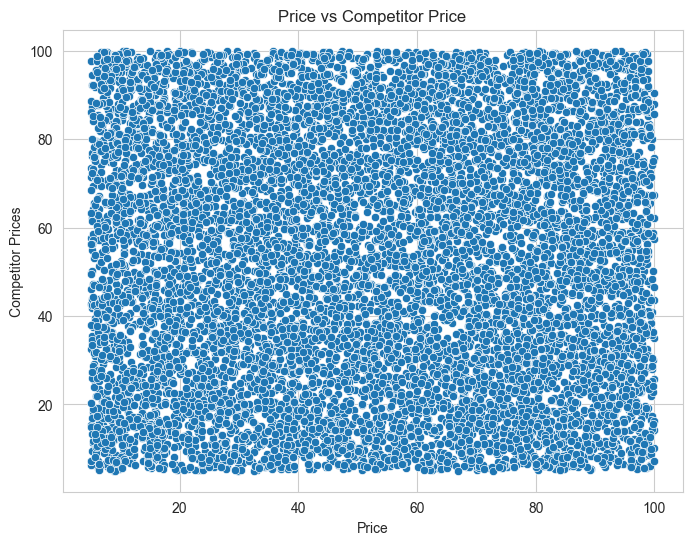

In [49]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pricing,
    x="Price",
    y="Competitor Prices"
)

plt.title("Price vs Competitor Price")
plt.savefig(
    "../reports/figures/pricing/price_vs_competitor_price.png",
    bbox_inches="tight"
)
plt.show()

Elasticity Analysis

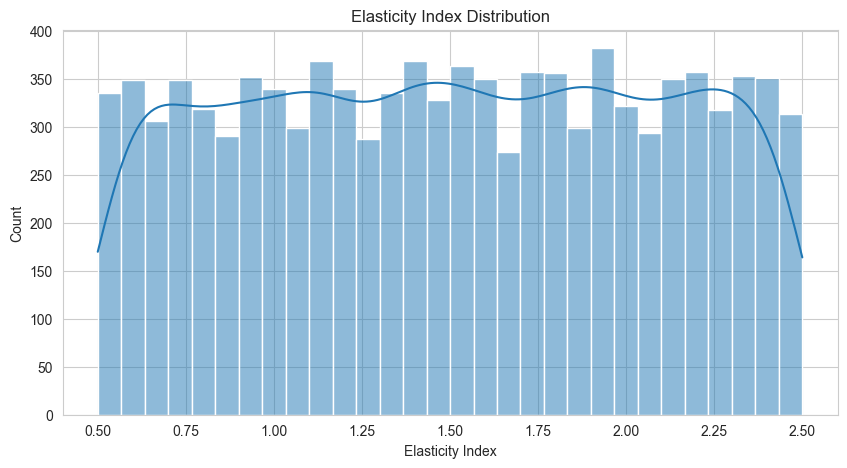

In [50]:
plt.figure(figsize=(10,5))

sns.histplot(
    pricing["Elasticity Index"],
    bins=30,
    kde=True
)

plt.title("Elasticity Index Distribution")
plt.savefig(
    "../reports/figures/pricing/elasticity_index_distribution.png",
    bbox_inches="tight"
)
plt.show()

In [23]:
demand.describe(include="all")

,Product ID,Date,Store ID,Sales Quantity,Price,Promotions,Seasonality Factors,External Factors,Demand Trend,Customer Segments
count,10000.000000,10000,10000.000000,10000.000000,10000.000000,10000,10000,10000,10000,10000
unique,NaN,NaN,NaN,NaN,NaN,2,3,4,3,3
top,NaN,NaN,NaN,NaN,NaN,Yes,Holiday,Weather,Increasing,Budget
freq,NaN,NaN,NaN,NaN,NaN,5023,3363,2556,3387,3412
mean,5533.521700,2024-06-30 12:30:57.600000,50.264900,248.728900,52.447878,NaN,NaN,NaN,NaN,NaN
min,1000.000000,2024-01-01 00:00:00,1.000000,1.000000,5.000000,NaN,NaN,NaN,NaN,NaN
25%,3319.000000,2024-03-31 00:00:00,26.000000,125.000000,28.480000,NaN,NaN,NaN,NaN,NaN
50%,5579.000000,2024-06-30 00:00:00,50.000000,249.000000,52.330000,NaN,NaN,NaN,NaN,NaN
75%,7696.500000,2024-09-30 00:00:00,75.000000,373.000000,76.252500,NaN,NaN,NaN,NaN,NaN
max,9998.000000,2024-12-30 00:00:00,99.000000,499.000000,99.990000,NaN,NaN,NaN,NaN,NaN


In [24]:
inventory.describe(include="all")

,Product ID,Store ID,Stock Levels,Supplier Lead Time (days),Stockout Frequency,Reorder Point,Expiry Date,Warehouse Capacity,Order Fulfillment Time (days)
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000.000000,10000.000000
mean,5534.614600,50.192900,502.119000,15.050000,9.495300,104.617500,2024-06-30 07:59:05.280000,2998.757400,7.544600
min,1000.000000,1.000000,0.000000,1.000000,0.000000,10.000000,2024-01-01 00:00:00,1000.000000,1.000000
25%,3235.750000,25.000000,253.000000,8.000000,5.000000,57.000000,2024-04-01 00:00:00,1971.500000,4.000000
50%,5559.000000,50.000000,498.000000,15.000000,9.000000,105.000000,2024-07-01 00:00:00,3016.000000,7.000000
75%,7841.250000,75.000000,751.000000,22.000000,15.000000,152.000000,2024-09-27 00:00:00,4011.000000,11.000000
max,9998.000000,99.000000,999.000000,29.000000,19.000000,199.000000,2024-12-30 00:00:00,4999.000000,14.000000
std,2619.330826,28.656605,288.888252,8.446362,5.774384,54.883156,NaN,1158.289745,4.036637


In [25]:
pricing.describe(include="all")

,Product ID,Store ID,Price,Competitor Prices,Discounts,Sales Volume,Customer Reviews,Return Rate (%),Storage Cost,Elasticity Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5526.073600,50.114100,52.704971,52.177523,25.142643,247.906200,2.488100,10.017396,5.535735,1.502381
std,2576.935584,28.720898,27.323341,27.585548,14.516326,143.680025,1.120707,5.773445,2.590201,0.576619
min,1000.000000,1.000000,5.020000,5.020000,0.000000,1.000000,1.000000,0.000000,1.000000,0.500000
25%,3290.000000,25.000000,29.197500,28.410000,12.710000,124.000000,1.000000,4.980000,3.310000,1.010000
50%,5551.000000,50.000000,53.100000,51.855000,24.940000,246.000000,2.000000,10.080000,5.580000,1.500000
75%,7732.500000,75.000000,76.460000,76.112500,37.810000,373.000000,3.000000,14.982500,7.770000,2.000000
max,9998.000000,99.000000,99.990000,99.990000,50.000000,499.000000,4.000000,20.000000,10.000000,2.500000


In [27]:
demand["Demand Trend"].value_counts()

Demand Trend
Increasing    3387
Stable        3354
Decreasing    3259
Name: count, dtype: int64

In [28]:
demand["Customer Segments"].value_counts()

Customer Segments
Budget     3412
Regular    3328
Premium    3260
Name: count, dtype: int64

In [29]:
inventory["Stockout Frequency"].describe()

count    10000.000000
mean         9.495300
std          5.774384
min          0.000000
25%          5.000000
50%          9.000000
75%         15.000000
max         19.000000
Name: Stockout Frequency, dtype: float64

In [30]:

pricing["Elasticity Index"].describe()

count    10000.000000
mean         1.502381
std          0.576619
min          0.500000
25%          1.010000
50%          1.500000
75%          2.000000
max          2.500000
Name: Elasticity Index, dtype: float64

Fast-Moving vs Slow-Moving Products


In [31]:
product_sales = (
    demand.groupby("Product ID")["Sales Quantity"]
    .sum()
    .sort_values(ascending=False)
)

product_sales.head(10)

Product ID
4584    1987
7860    1880
7694    1824
1539    1806
4555    1686
7845    1637
7398    1626
1413    1623
8990    1613
2222    1609
Name: Sales Quantity, dtype: int64

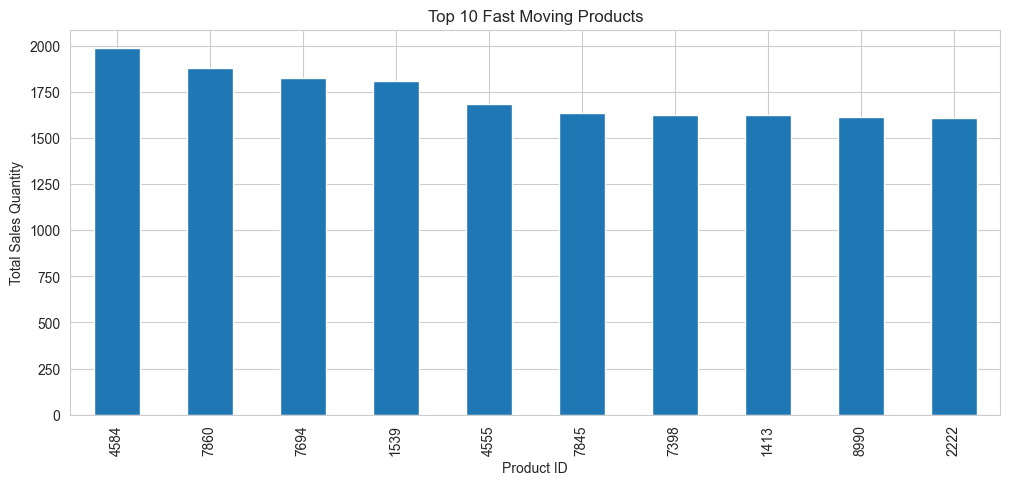

In [51]:
top10 = product_sales.head(10)

plt.figure(figsize=(12,5))

top10.plot(kind="bar")

plt.title("Top 10 Fast Moving Products")
plt.ylabel("Total Sales Quantity")
plt.savefig(
    "../reports/figures/demand/Top 10 Fast Moving Products.png",
    bbox_inches="tight"
)
plt.show()

Slow-moving products:

In [33]:
product_sales.tail(10)

Product ID
2089    2
7011    2
8633    2
5040    2
4402    2
6321    2
7689    1
4245    1
6792    1
3846    1
Name: Sales Quantity, dtype: int64

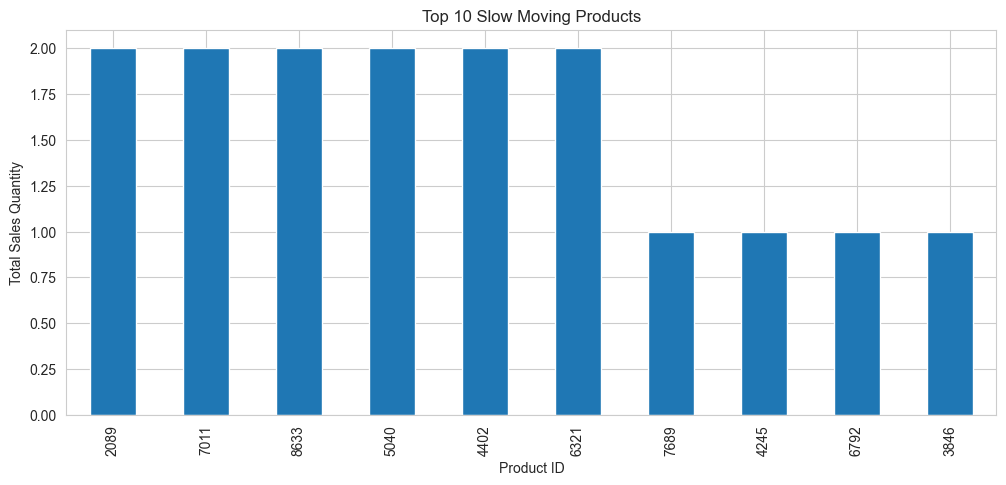

In [52]:
bottom10 = product_sales.tail(10)

plt.figure(figsize=(12,5))

bottom10.plot(kind="bar")

plt.title("Top 10 Slow Moving Products")
plt.ylabel("Total Sales Quantity")
plt.savefig(
    "../reports/figures/demand/Top 10 Slow Moving Products.png",
    bbox_inches="tight"
)
plt.show()

Demand Variability Analysis

In [35]:
variability = (
    demand.groupby("Product ID")["Sales Quantity"]
    .agg(["mean","std"])
)

variability["CV"] = (
    variability["std"]
    /
    variability["mean"]
)

** CV (Coefficient of Variation) **

In [36]:
variability.head()

,mean,std,CV
Product ID,,,
1000,237.333333,28.290163,0.11920
1001,234.333333,236.034602,1.00726
1003,400.000000,NaN,NaN
1005,245.000000,NaN,NaN
1006,137.000000,NaN,NaN


Most varible product

In [37]:
variability.sort_values(
    "CV",
    ascending=False
).head(10)

,mean,std,CV
Product ID,,,
4991,118.250000,185.851868,1.571686
1663,165.000000,252.025792,1.527429
4180,174.000000,265.020754,1.523108
4671,143.000000,209.980952,1.468398
2995,178.666667,260.308151,1.456949
6239,85.000000,122.747709,1.444091
2489,110.000000,155.019354,1.409267
1839,239.000000,336.582828,1.408296
2883,214.000000,301.227489,1.407605


Least variable product

In [38]:
variability.sort_values(
    "CV"
).head(10)

,mean,std,CV
Product ID,,,
5760,40.0,0.000000,0.000000
9265,115.0,0.000000,0.000000
5019,276.0,0.000000,0.000000
1234,430.5,0.707107,0.001643
1170,414.5,0.707107,0.001706
3824,304.5,0.707107,0.002322
6078,407.0,1.414214,0.003475
1594,403.0,1.414214,0.003509
5197,317.0,1.414214,0.004461


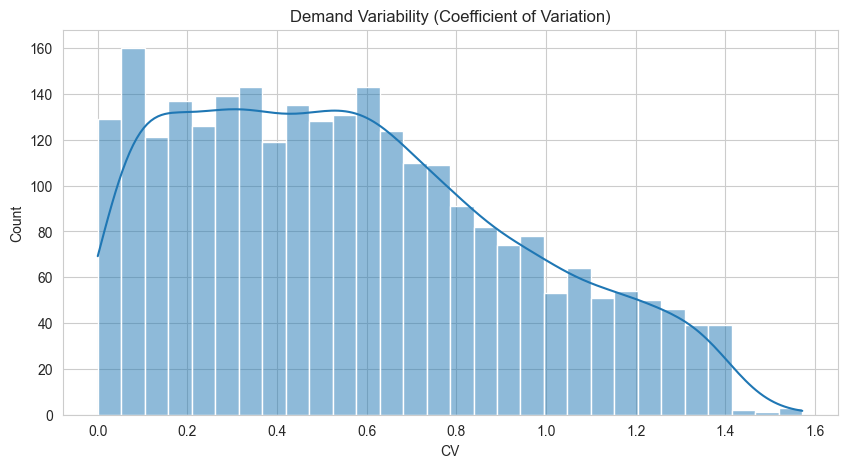

In [53]:
plt.figure(figsize=(10,5))

sns.histplot(
    variability["CV"],
    bins=30,
    kde=True
)

plt.title("Demand Variability (Coefficient of Variation)")
plt.savefig(
    "../reports/figures/demand/demand_variability.png",
    bbox_inches="tight"
)
plt.show()

In [40]:
import os

os.makedirs("../reports/figures/demand", exist_ok=True)
os.makedirs("../reports/figures/inventory", exist_ok=True)
os.makedirs("../reports/figures/pricing", exist_ok=True)

# Demand Variability Categories

In [54]:
variability.head()

,mean,std,CV
Product ID,,,
1000,237.333333,28.290163,0.11920
1001,234.333333,236.034602,1.00726
1003,400.000000,NaN,NaN
1005,245.000000,NaN,NaN
1006,137.000000,NaN,NaN


In [55]:
product_counts = demand["Product ID"].value_counts()

print(product_counts.describe())

count    6065.000000
mean        1.648805
std         0.883179
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         9.000000
Name: count, dtype: float64


In [56]:
print("Products with only one record:")
print((product_counts == 1).sum())

Products with only one record:
3384


In [57]:
print("Total unique products:")
print(demand["Product ID"].nunique())

Total unique products:
6065


keep the variability analysis but exclude products with only one observation.

In [58]:
variability_valid = variability.dropna(subset=["CV"])

In [59]:
print(variability_valid.shape)
variability_valid.head()

(2681, 3)


,mean,std,CV
Product ID,,,
1000,237.333333,28.290163,0.119200
1001,234.333333,236.034602,1.007260
1008,304.000000,135.624482,0.446133
1009,84.000000,90.149875,1.073213
1013,336.500000,178.898016,0.531643


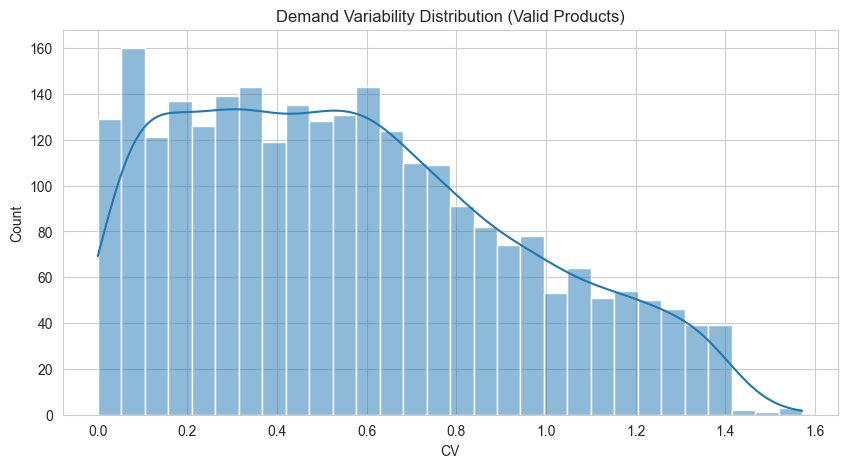

In [60]:
plt.figure(figsize=(10,5))

sns.histplot(
    variability_valid["CV"],
    bins=30,
    kde=True
)

plt.title("Demand Variability Distribution (Valid Products)")

plt.savefig(
    "../reports/figures/demand/sales_quantity_distribution.png",
    bbox_inches="tight"
)


plt.show()

Adding Variability Categories

In [62]:
variability_valid = variability.dropna(subset=["CV"]).copy()

variability_valid["Demand_Type"] = variability_valid["CV"].apply(
    lambda x: "Stable" if x < 0.5 else "Variable"
)

In [63]:
variability_valid["Demand_Type"].value_counts()

Demand_Type
Variable    1405
Stable      1276
Name: count, dtype: int64

In [66]:
print(
    demand[["Product ID","Store ID"]]
    .duplicated()
    .sum()
)

print(
    inventory[["Product ID","Store ID"]]
    .duplicated()
    .sum()
)

print(
    pricing[["Product ID","Store ID"]]
    .duplicated()
    .sum()
)

59
47
52


In [67]:
print("Demand unique pairs:")
print(
    demand[["Product ID","Store ID"]]
    .drop_duplicates()
    .shape
)

print("\nInventory unique pairs:")
print(
    inventory[["Product ID","Store ID"]]
    .drop_duplicates()
    .shape
)

print("\nPricing unique pairs:")
print(
    pricing[["Product ID","Store ID"]]
    .drop_duplicates()
    .shape
)

Demand unique pairs:
(9941, 2)

Inventory unique pairs:
(9953, 2)

Pricing unique pairs:
(9948, 2)


In [68]:
demand_merge_test = demand.merge(
    inventory,
    on=["Product ID","Store ID"],
    how="inner"
)

print("Demand + Inventory:", demand_merge_test.shape)

Demand + Inventory: (122, 17)


Verification 

In [69]:
print("Demand Products:", demand["Product ID"].nunique())
print("Inventory Products:", inventory["Product ID"].nunique())
print("Pricing Products:", pricing["Product ID"].nunique())

Demand Products: 6065
Inventory Products: 6031
Pricing Products: 6061


In [70]:
print(
    len(
        set(demand["Product ID"])
        &
        set(inventory["Product ID"])
    )
)

print(
    len(
        set(demand["Product ID"])
        &
        set(pricing["Product ID"])
    )
)

4081
4124
